<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 16px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e94560; font-size: 2.4em; margin: 0; letter-spacing: 2px;">🌿 XGBoost — Skin Type Classification</h1>
  <p style="color: #a8dadc; font-size: 1.1em; margin-top: 12px;">Predicting <strong>Dry · Normal · Oily</strong> skin types from biometric &amp; environmental features</p>
  <hr style="border: 1px solid #e94560; width: 60%; margin: 20px auto;"/>
  <p style="color: #888; font-size: 0.9em;">Pipeline · Baseline · GridSearchCV · RandomizedSearchCV · Visualizations · Feature Importance</p>
</div>

---
## ⚙️ Step 1 — Import Required Libraries

In [10]:
# Uncomment if XGBoost is not yet installed
#!pip install xgboost --quiet

import xgboost as xgb
print(f"XGBoost version : {xgb.__version__}")

XGBoost version : 3.2.0


In [11]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# --- Global style -------------------------------------------------------
plt.rcParams.update({
    'figure.dpi'      : 110,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
})
PALETTE = ['#e94560', '#0f3460', '#16213e', '#a8dadc', '#f5a623', '#7ed321']
sns.set_palette(PALETTE)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## 📂 Step 2 — Load & Explore the Dataset

In [12]:
# ── Load ────────────────────────────────────────────────────────────────────────
# Replace the filename below with the actual path to your CSV file.
# On Google Colab you can upload it first:
#   from google.colab import files; files.upload()

df = pd.read_csv('Skin_Type_dataset.csv')   # ← adapt filename

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape : 10,000 rows × 10 columns


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,skin_score,skin_age
0,31,Female,Medium,High,Low,53.0,16.9,Oily,100.0,15.0
1,42,Male,Low,Low,High,32.6,15.4,Dry,36.8,62.0
2,36,Male,Medium,Medium,Low,65.5,14.0,Normal,100.0,24.5
3,35,Male,Medium,High,Medium,49.4,17.7,Normal,100.0,16.2
4,41,Male,Medium,High,Low,62.7,30.2,Oily,100.0,25.3


In [13]:
# ── General information ──────────────────────────────────────────────────────
print("=" * 55)
print(" COLUMN TYPES & MISSING VALUES")
print("=" * 55)
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non-null': df.notnull().sum(),
    'missing' : df.isnull().sum(),
    'unique'  : df.nunique()
})
print(info)
print()
print("=" * 55)
print(" DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe(include='all').round(3)

 COLUMN TYPES & MISSING VALUES
                   dtype  non-null  missing  unique
Age                int64     10000        0      42
Gender            object     10000        0       2
Hydration_Level   object     10000        0       3
Oil_Level         object     10000        0       3
Sensitivity       object     10000        0       3
Humidity         float64     10000        0     601
Temperature      float64     10000        0     249
Skin_Type         object     10000        0       4
skin_score       float64     10000        0     845
skin_age         float64     10000        0     594

 DESCRIPTIVE STATISTICS


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,skin_score,skin_age
count,10000.000,10000,10000,10000,10000,10000.000,10000.000,10000,10000.000,10000.000
unique,NaN,2,3,3,3,NaN,NaN,4,NaN,NaN
top,NaN,Male,Low,Medium,Medium,NaN,NaN,Normal,NaN,NaN
freq,NaN,5790,4169,3638,3696,NaN,NaN,3084,NaN,NaN
mean,40.842,NaN,NaN,NaN,NaN,49.970,20.120,NaN,76.323,36.529
std,12.031,NaN,NaN,NaN,NaN,16.987,5.574,NaN,26.656,17.752
min,18.000,NaN,NaN,NaN,NaN,20.000,10.000,NaN,2.300,15.000
25%,31.000,NaN,NaN,NaN,NaN,34.400,15.700,NaN,49.600,21.800
50%,41.000,NaN,NaN,NaN,NaN,49.600,18.900,NaN,90.000,33.500
75%,52.000,NaN,NaN,NaN,NaN,62.800,24.600,NaN,100.000,47.600


Class distribution:
Skin_Type
Normal         3084
Oily           2944
Dry            2500
Combination    1472

Class balance (%):
Skin_Type
Normal         30.84
Oily           29.44
Dry            25.00
Combination    14.72


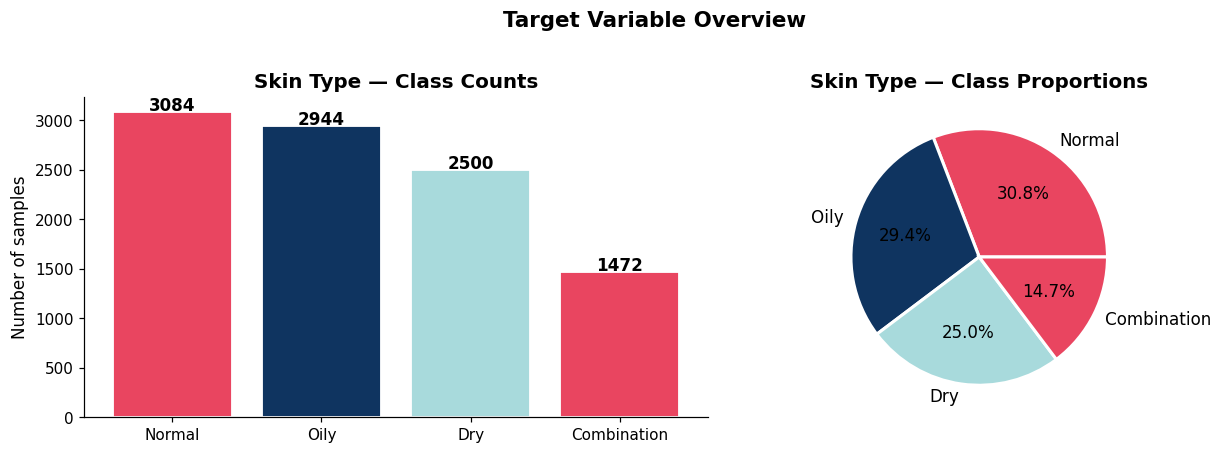

In [14]:
# ── Target distribution ──────────────────────────────────────────────────────
counts = df['Skin_Type'].value_counts()
print("Class distribution:")
print(counts.to_string())
print(f"\nClass balance (%):\n{(counts / len(df) * 100).round(2).to_string()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(counts.index, counts.values,
                   color=['#e94560', '#0f3460', '#a8dadc'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Skin Type — Class Counts', fontweight='bold')
axes[0].set_ylabel('Number of samples')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10, str(val),
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#e94560', '#0f3460', '#a8dadc'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Skin Type — Class Proportions', fontweight='bold')

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

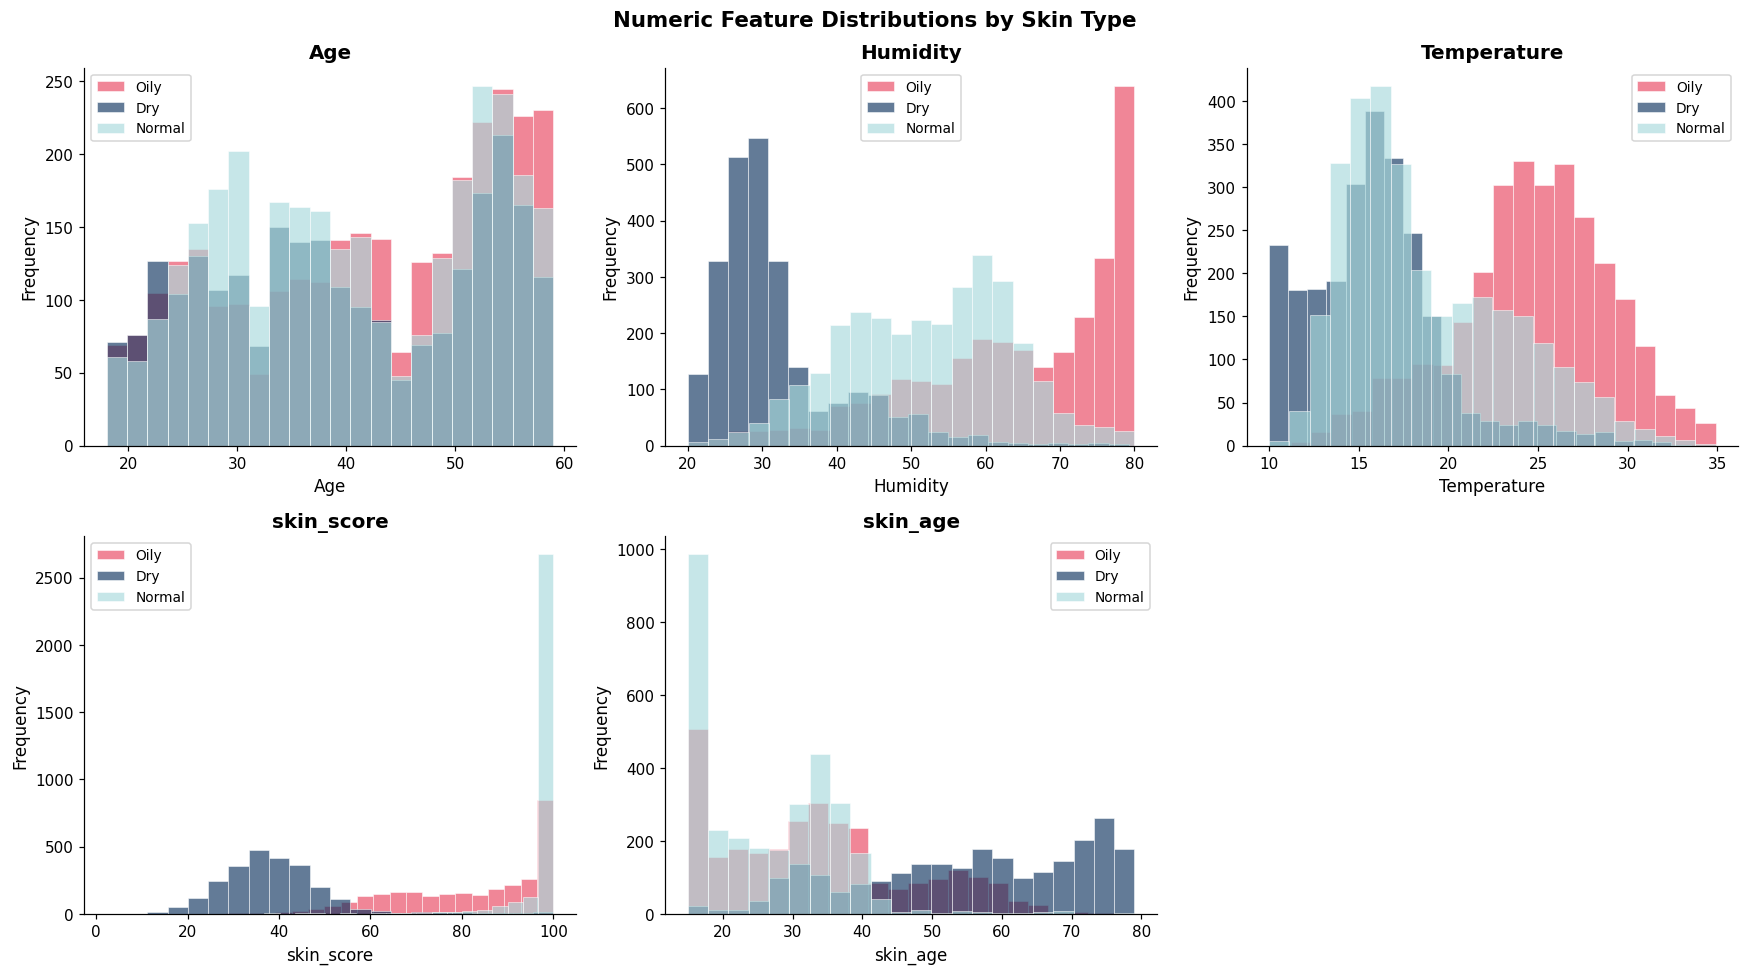

In [15]:
# ── Numeric features — distribution by skin type ────────────────────────────
numeric_cols = ['Age', 'Humidity', 'Temperature', 'skin_score', 'skin_age']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = {'Oily': '#e94560', 'Dry': '#0f3460', 'Normal': '#a8dadc'}

for i, col in enumerate(numeric_cols):
    for skin_type, color in colors.items():
        subset = df[df['Skin_Type'] == skin_type][col].dropna()
        axes[i].hist(subset, bins=22, alpha=0.65, label=skin_type,
                     color=color, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions by Skin Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

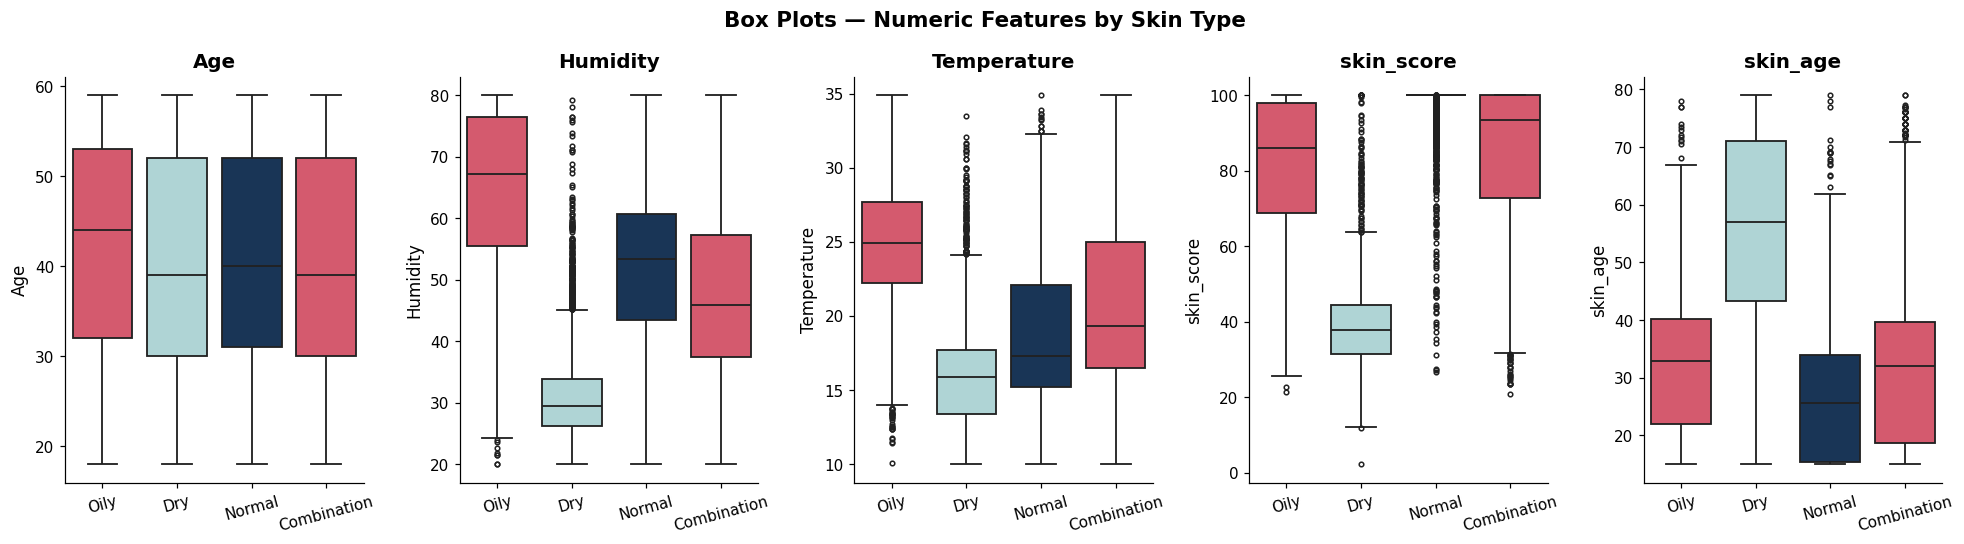

In [16]:
# ── Box plots — numeric features by skin type ────────────────────────────────
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Skin_Type', y=col, ax=ax,
                palette=['#e94560', '#a8dadc', '#0f3460'],
                linewidth=1.2, flierprops={'marker': 'o', 'markersize': 3})
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Box Plots — Numeric Features by Skin Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

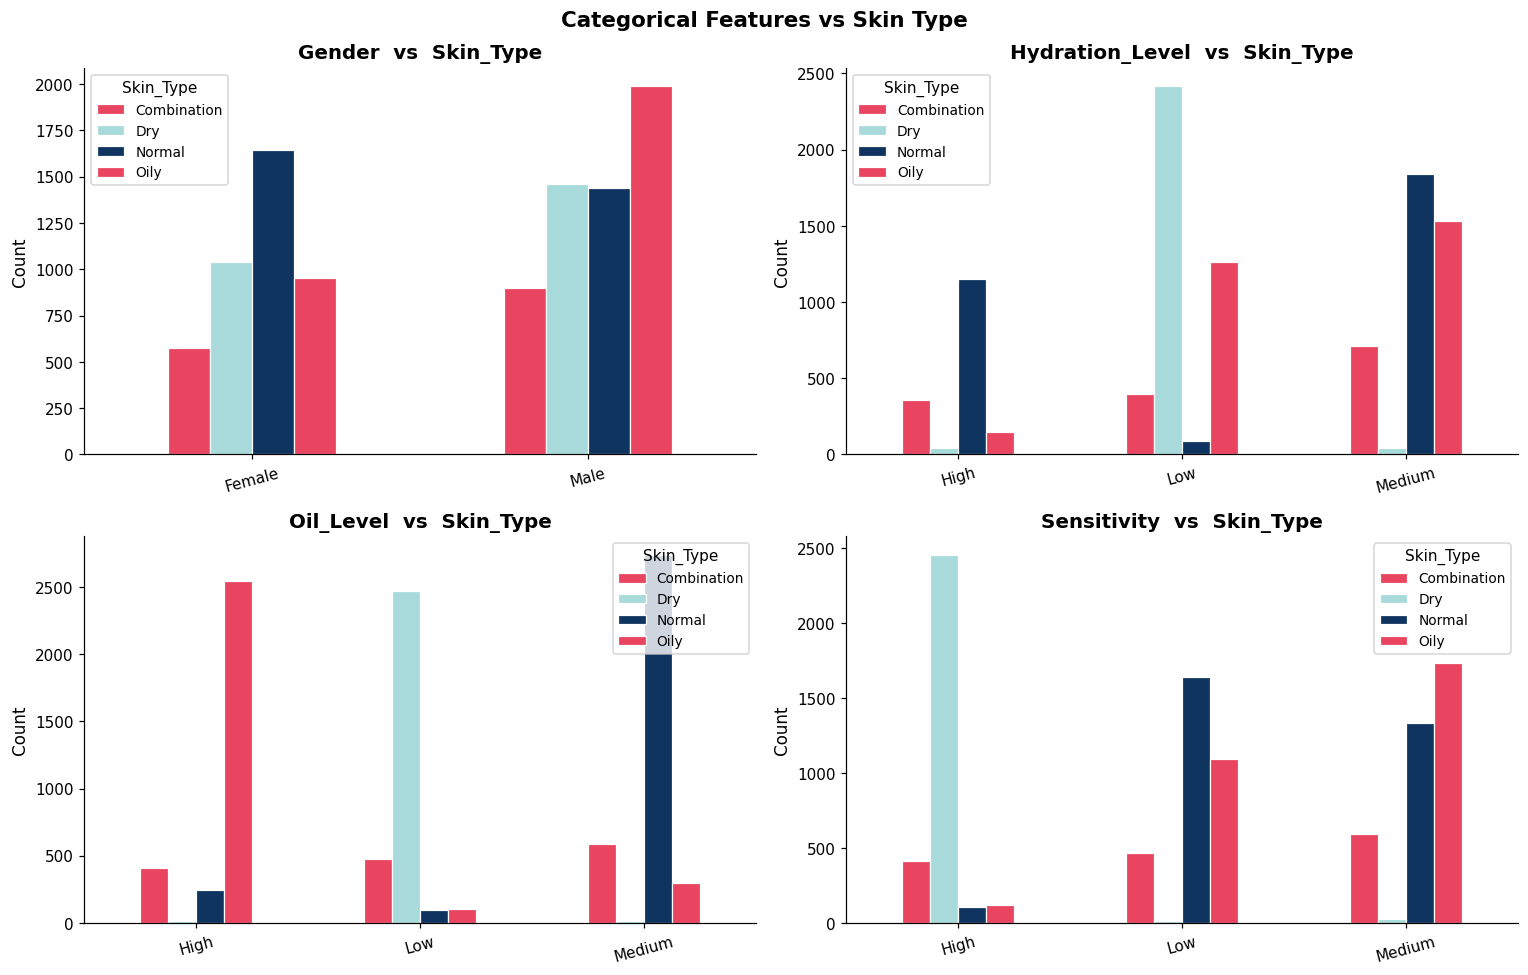

In [17]:
# ── Categorical features vs target ──────────────────────────────────────────
cat_cols = ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Skin_Type'])
    ct.plot(kind='bar', ax=axes[i], color=['#e94560', '#a8dadc', '#0f3460'],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col}  vs  Skin_Type', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='Skin_Type', fontsize=9)

plt.suptitle('Categorical Features vs Skin Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

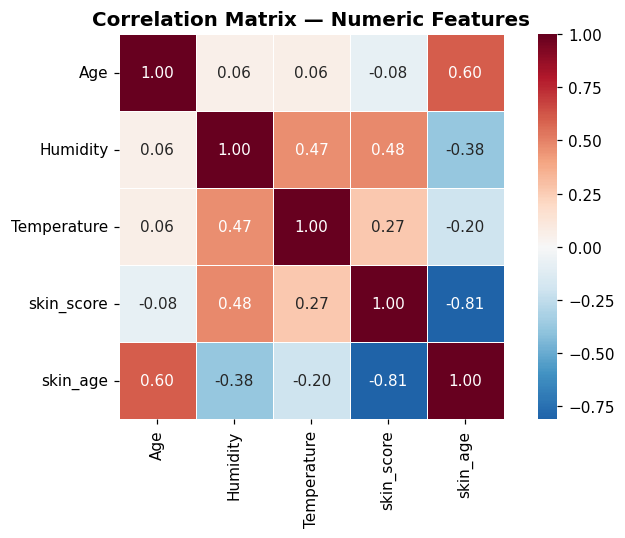

In [18]:
# ── Correlation heatmap (numeric columns) ───────────────────────────────────
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Correlation Matrix — Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🔧 Step 3 — Preprocessing & Train-Test Split

In [19]:
# ── Label Encoding — categorical features ───────────────────────────────────
df_enc = df.copy()

cat_features = ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity']
le_dict = {}

for col in cat_features:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    le_dict[col] = le
    print(f"  {col:<18} → {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target
le_target = LabelEncoder()
df_enc['Skin_Type'] = le_target.fit_transform(df_enc['Skin_Type'])
CLASS_NAMES = le_target.classes_
print(f"\n  Skin_Type → {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print(f"  Classes   : {list(CLASS_NAMES)}")

  Gender             → {'Female': np.int64(0), 'Male': np.int64(1)}
  Hydration_Level    → {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
  Oil_Level          → {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
  Sensitivity        → {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

  Skin_Type → {'Combination': np.int64(0), 'Dry': np.int64(1), 'Normal': np.int64(2), 'Oily': np.int64(3)}
  Classes   : ['Combination', 'Dry', 'Normal', 'Oily']


In [20]:
# ── Feature / target separation ─────────────────────────────────────────────
FEATURES = ['Age', 'Gender', 'Hydration_Level', 'Oil_Level',
            'Sensitivity', 'Humidity', 'Temperature']
# Optional: include skin_score and skin_age (may cause leakage — use carefully)
# FEATURES += ['skin_score', 'skin_age']

X = df_enc[FEATURES]
y = df_enc['Skin_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]:>5} samples")
print(f"Test set       : {X_test.shape[0]:>5} samples")
print(f"Features used  : {FEATURES}")
print(f"\ny_train distribution:\n{pd.Series(y_train).value_counts().to_string()}")

Training set   :  8000 samples
Test set       :  2000 samples
Features used  : ['Age', 'Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity', 'Humidity', 'Temperature']

y_train distribution:
Skin_Type
2    2467
3    2355
1    2000
0    1178


---
## 🚀 Step 4 — XGBoost Baseline (Multiclass Classification)

> Our target has **3 classes** (Dry, Normal, Oily) so we use `objective='multi:softmax'` with `num_class=3`.  
> XGBoost does **not** require feature scaling, but we keep this in mind if combining with sklearn pipelines.

In [21]:
N_CLASSES = len(CLASS_NAMES)

# ── Baseline XGBoost classifier ─────────────────────────────────────────────
classifier = XGBClassifier(
    objective        = 'multi:softmax',   # multiclass classification
    num_class        = N_CLASSES,         # number of skin types
    learning_rate    = 0.1,               # step size shrinkage (eta)
    max_depth        = 4,                 # maximum tree depth
    n_estimators     = 150,               # number of boosting rounds
    subsample        = 0.8,               # fraction of training samples per tree
    colsample_bytree = 0.8,               # fraction of features per tree
    gamma            = 0,                 # minimum loss reduction for split
    reg_alpha        = 0,                 # L1 regularization
    reg_lambda       = 1,                 # L2 regularization
    min_child_weight = 1,                 # minimum child weight
    use_label_encoder= False,
    random_state     = 42,
    verbosity        = 0
)

# ── Training with eval set ──────────────────────────────────────────────────
classifier.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# ── Predictions & accuracy ──────────────────────────────────────────────────
y_pred_base = classifier.predict(X_test)
acc_base    = accuracy_score(y_test, y_pred_base)

print(f"\n{'='*45}")
print(f"  Baseline XGBoost Accuracy : {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"{'='*45}")


  Baseline XGBoost Accuracy : 0.7860 (78.60%)


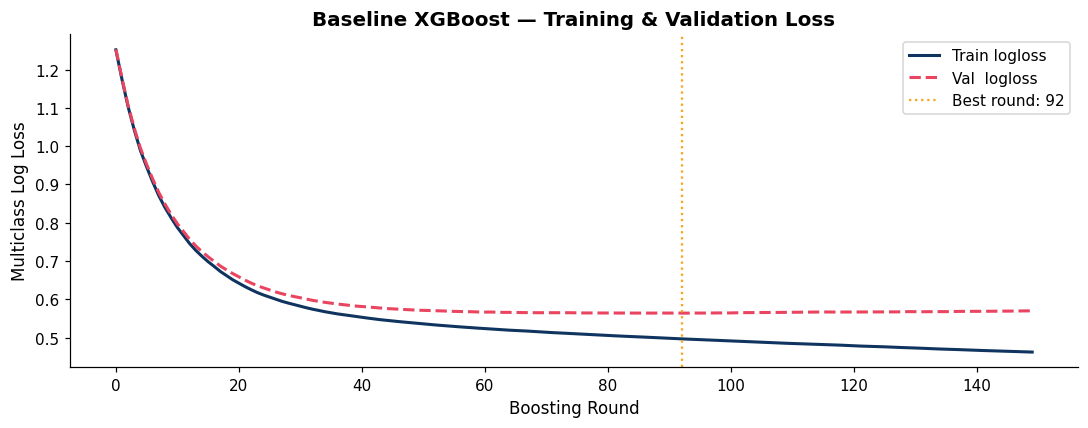

Minimum validation logloss : 0.5639  at round 92


In [22]:
# ── Training vs Validation loss curve ───────────────────────────────────────
evals_result = classifier.evals_result()

train_loss = evals_result['validation_0']['mlogloss']
val_loss   = evals_result['validation_1']['mlogloss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train logloss', color='#0f3460', linewidth=2)
plt.plot(val_loss,   label='Val  logloss',  color='#e94560', linewidth=2, linestyle='--')
best_round = int(np.argmin(val_loss))
plt.axvline(best_round, color='#f5a623', linestyle=':', linewidth=1.5,
            label=f'Best round: {best_round}')
plt.title('Baseline XGBoost — Training & Validation Loss', fontweight='bold')
plt.xlabel('Boosting Round')
plt.ylabel('Multiclass Log Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Minimum validation logloss : {min(val_loss):.4f}  at round {best_round}")

5-Fold CV Accuracy scores : [0.797  0.7975 0.7905 0.7915 0.7995]
Mean  : 0.7952
Std   : 0.0035


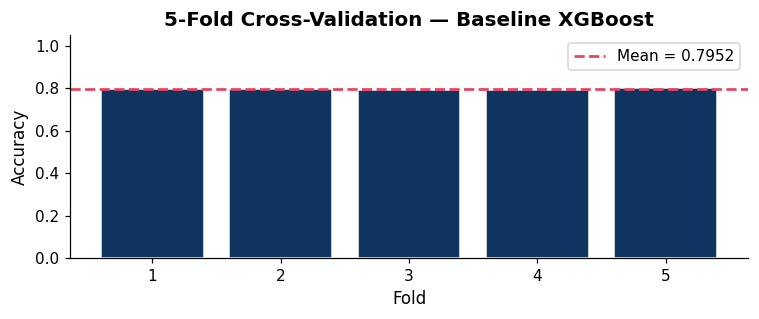

In [23]:
# ── 5-fold cross-validation (baseline) ─────────────────────────────────────
cv_scores = cross_val_score(classifier, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print("5-Fold CV Accuracy scores :", np.round(cv_scores, 4))
print(f"Mean  : {cv_scores.mean():.4f}")
print(f"Std   : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), cv_scores, color='#0f3460', edgecolor='white')
plt.axhline(cv_scores.mean(), color='#e94560', linestyle='--', linewidth=1.8,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0, 1.05)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation — Baseline XGBoost', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔍 Step 5 — Hyperparameter Tuning

We will try **three strategies**:

| Strategy | Speed | Coverage |
|---|---|---|
| Full GridSearchCV | 🐢 Very slow — **DO NOT EXECUTE** | Exhaustive |
| Reduced GridSearchCV | 🐇 Fast | Good |
| RandomizedSearchCV | ⚡ Fastest | Probabilistic |




```
# This is formatted as code
```

### 🐢 Strategy A — Full GridSearchCV *(Do NOT Execute — very slow)*

In [24]:
# ⚠️  DO NOT EXECUTE — this cell can take 30+ minutes ⚠️

param_grid_full = {
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [3, 5, 7, 9],
    'n_estimators'     : [100, 200, 300],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'gamma'            : [0, 0.5, 1],
    'reg_alpha'        : [0, 1, 10],
    'reg_lambda'       : [1, 10]
}

# Total combinations = 4×4×3×3×3×3×3×2 = 7776  ← exhaustive!
grid_full = GridSearchCV(
    XGBClassifier(objective='multi:softmax', num_class=N_CLASSES,
                  use_label_encoder=False, verbosity=0, random_state=42),
    param_grid_full,
    scoring='accuracy', cv=5, n_jobs=-1, verbose=1
)
# grid_full.fit(X_train, y_train)  # ← commented out intentionally

### 🐇 Strategy B — Reduced GridSearchCV

**Optimizations applied vs full grid:**
1. **Reduced search space** — fewer options per hyperparameter
2. **3-fold CV** instead of 5 → ~40% fewer model fits
3. **`n_jobs=-1`** → all CPU cores used in parallel

In [25]:
param_grid_fast = {
    'learning_rate'    : [0.05, 0.1],
    'max_depth'        : [3, 5, 7],
    'n_estimators'     : [100, 200],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'gamma'            : [0, 0.5],
    'reg_alpha'        : [0, 1],
    'reg_lambda'       : [1, 10]
}
# 2×3×2×2×2×2×2×2 = 384 combinations with cv=3 → 1152 fits

grid_fast = GridSearchCV(
    XGBClassifier(objective='multi:softmax', num_class=N_CLASSES,
                  use_label_encoder=False, verbosity=0, random_state=42),
    param_grid_fast,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
grid_fast.fit(X_train, y_train)
t_grid = time.time() - t0

print(f"\n⏱  GridSearchCV (reduced) finished in {t_grid:.1f}s")
print(f"   Best params   : {grid_fast.best_params_}")
print(f"   Best CV score : {grid_fast.best_score_:.4f}")

best_model_grid = grid_fast.best_estimator_
y_pred_grid     = best_model_grid.predict(X_test)
acc_grid        = accuracy_score(y_test, y_pred_grid)
print(f"   Test Accuracy : {acc_grid:.4f} ({acc_grid*100:.2f}%)")

Fitting 3 folds for each of 384 candidates, totalling 1152 fits

⏱  GridSearchCV (reduced) finished in 538.7s
   Best params   : {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 10, 'subsample': 0.8}
   Best CV score : 0.8001
   Test Accuracy : 0.7930 (79.30%)


### ⚡ Strategy C — RandomizedSearchCV

**Why RandomizedSearch is often better in practice:**
- Randomly samples `n_iter` combinations instead of evaluating all of them
- Explores a **wider** parameter space in less time
- Converges to good solutions fast — especially useful with large grids

In [26]:
param_dist = {
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'n_estimators'     : [100, 150, 200, 250, 300],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 1.0],
    'gamma'            : [0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha'        : [0, 0.1, 1, 5, 10],
    'reg_lambda'       : [0, 1, 5, 10, 20],
    'min_child_weight' : [1, 3, 5]
}

random_search = RandomizedSearchCV(
    XGBClassifier(objective='multi:softmax', num_class=N_CLASSES,
                  use_label_encoder=False, verbosity=0, random_state=42),
    param_distributions=param_dist,
    n_iter=40,          # number of random combinations to try
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

t0 = time.time()
random_search.fit(X_train, y_train)
t_rand = time.time() - t0

print(f"\n⏱  RandomizedSearchCV finished in {t_rand:.1f}s")
print(f"   Best params   : {random_search.best_params_}")
print(f"   Best CV score : {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred     = best_model.predict(X_test)
acc_rand   = accuracy_score(y_test, y_pred)
print(f"   Test Accuracy : {acc_rand:.4f} ({acc_rand*100:.2f}%)")

Fitting 3 folds for each of 40 candidates, totalling 120 fits

⏱  RandomizedSearchCV finished in 61.5s
   Best params   : {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.3, 'gamma': 1.0, 'colsample_bytree': 0.5}
   Best CV score : 0.7995
   Test Accuracy : 0.7895 (78.95%)


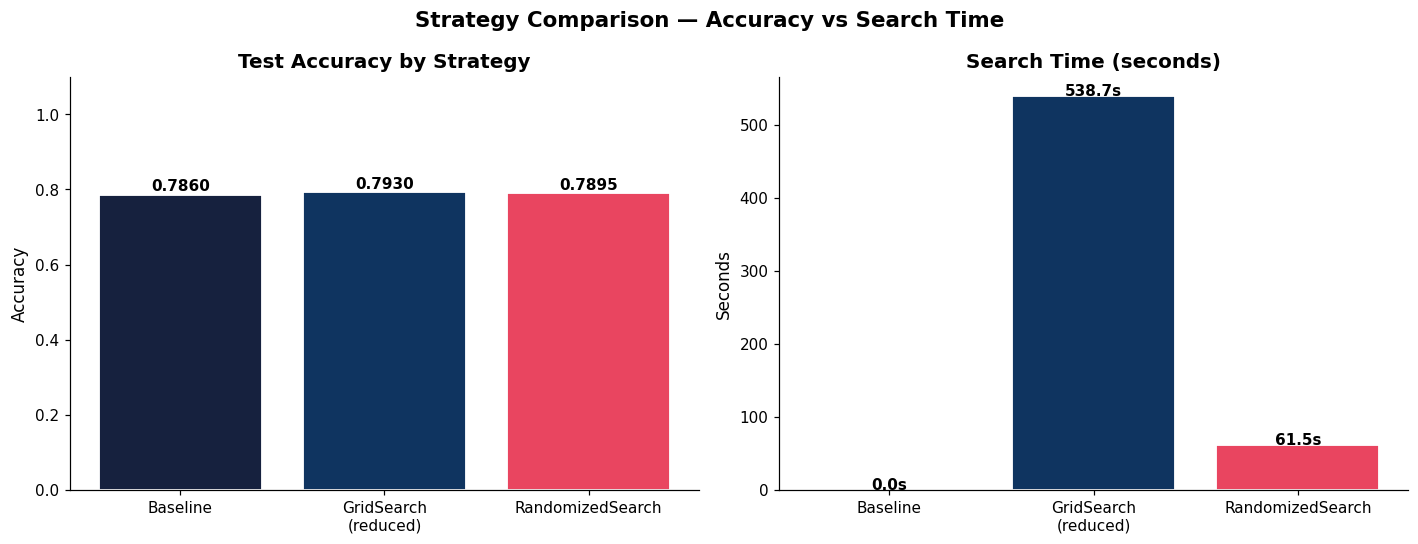

In [27]:
# ── Speed vs Accuracy comparison ────────────────────────────────────────────
strategies   = ['Baseline', 'GridSearch\n(reduced)', 'RandomizedSearch']
accuracies   = [acc_base, acc_grid, acc_rand]
times        = [0, t_grid, t_rand]  # baseline has no search overhead

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy
bars = axes[0].bar(strategies, accuracies,
                   color=['#16213e', '#0f3460', '#e94560'], edgecolor='white', linewidth=1.2)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Test Accuracy by Strategy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
for bar, v in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
                 ha='center', fontsize=10, fontweight='bold')

# Time
bars2 = axes[1].bar(strategies, times,
                    color=['#a8dadc', '#0f3460', '#e94560'], edgecolor='white', linewidth=1.2)
axes[1].set_title('Search Time (seconds)', fontweight='bold')
axes[1].set_ylabel('Seconds')
for bar, v in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}s',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Strategy Comparison — Accuracy vs Search Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Step 6 — Evaluation & Visualizations

Using the **best model** found by RandomizedSearchCV.

In [28]:
# ── Classification report ────────────────────────────────────────────────────
print("=" * 55)
print("  CLASSIFICATION REPORT — Best Model")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

  CLASSIFICATION REPORT — Best Model
              precision    recall  f1-score   support

 Combination       0.48      0.24      0.32       294
         Dry       0.92      0.95      0.93       500
      Normal       0.76      0.86      0.81       617
        Oily       0.79      0.85      0.82       589

    accuracy                           0.79      2000
   macro avg       0.74      0.73      0.72      2000
weighted avg       0.77      0.79      0.77      2000



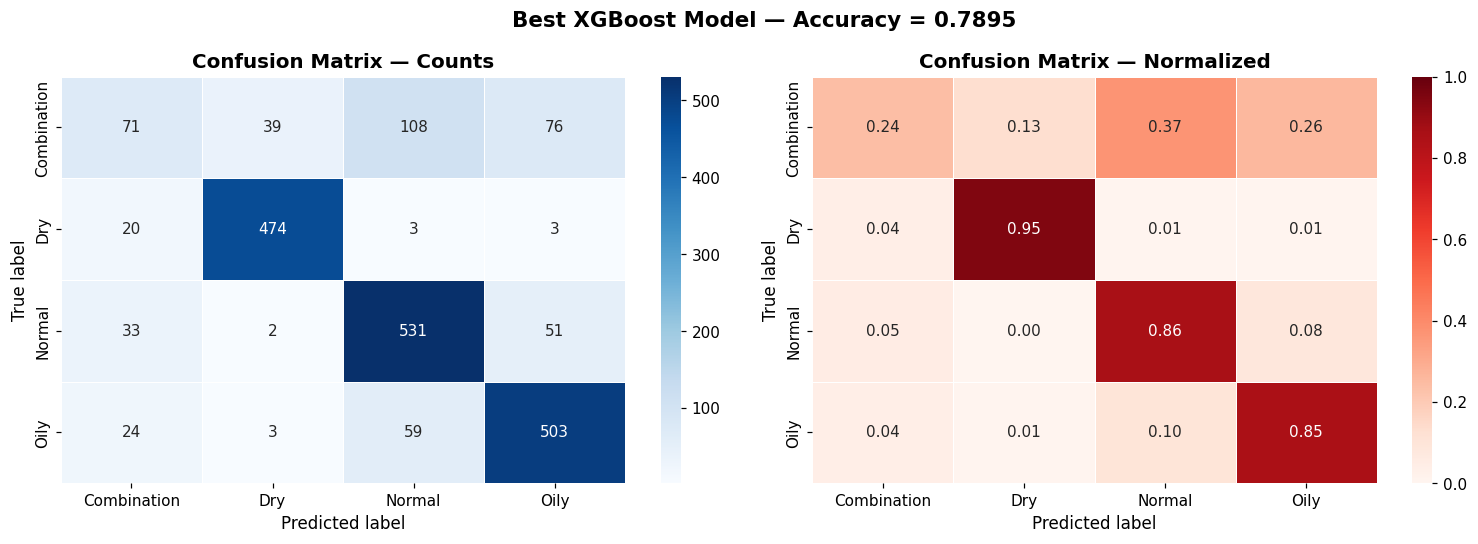

In [29]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0, vmax=1, linewidths=0.5, linecolor='white')
axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.suptitle(f'Best XGBoost Model — Accuracy = {acc_rand:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

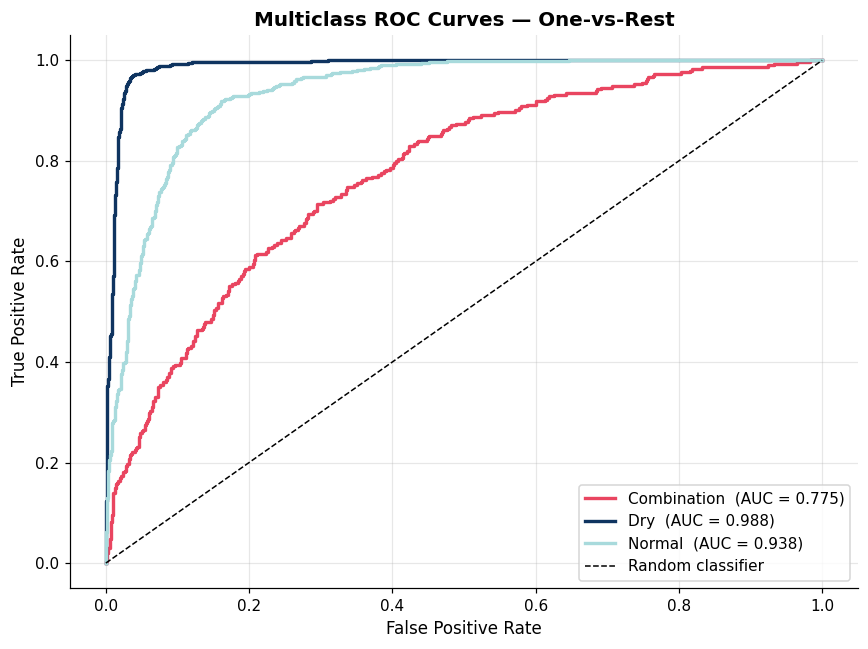

Macro-average AUC : 0.9132
  Combination AUC : 0.7753
  Dry      AUC : 0.9883
  Normal   AUC : 0.9378


In [30]:
# ── Multiclass ROC Curve (One-vs-Rest) ──────────────────────────────────────
# Binarize test labels for OvR ROC
y_test_bin  = label_binarize(y_test, classes=list(range(N_CLASSES)))
y_prob      = best_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))
colors_roc  = ['#e94560', '#0f3460', '#a8dadc']

auc_scores = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=col, linewidth=2.2,
             label=f'{cls}  (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves — One-vs-Rest', fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
print(f"Macro-average AUC : {macro_auc:.4f}")
for cls, sc in zip(CLASS_NAMES, auc_scores):
    print(f"  {cls:<8} AUC : {sc:.4f}")

---
## 🌳 Step 7 — Feature Importance

<Figure size 990x550 with 0 Axes>

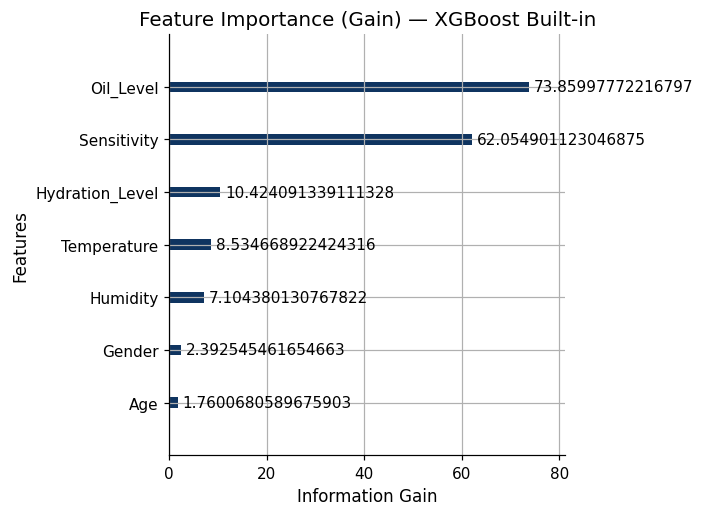

In [31]:
# ── 1. Built-in XGBoost plot_importance ─────────────────────────────────────
plt.figure(figsize=(9, 5))
xgb.plot_importance(
    best_model,
    importance_type='gain',    # 'weight', 'cover', or 'gain'
    title='Feature Importance (Gain) — XGBoost Built-in',
    xlabel='Information Gain',
    color='#0f3460'
)
plt.tight_layout()
plt.show()

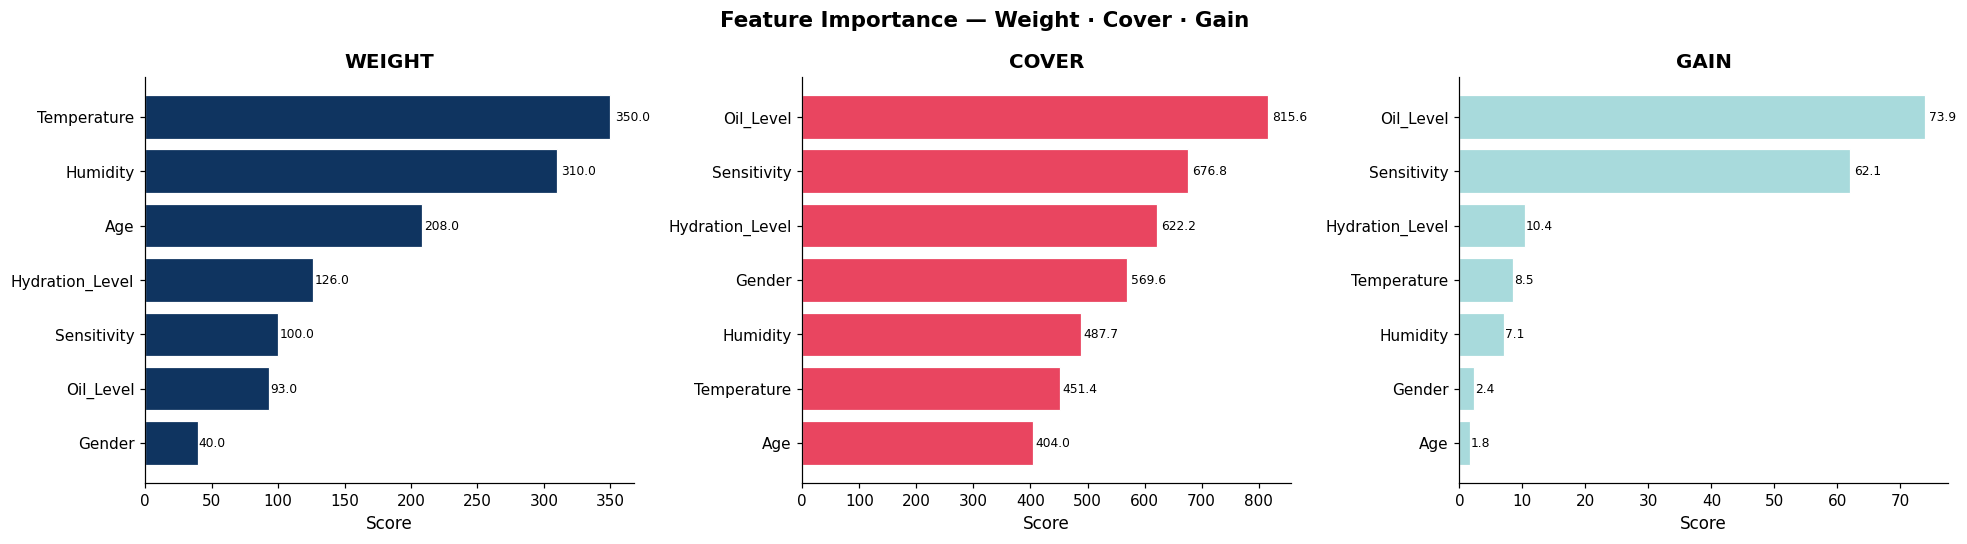

In [32]:
# ── 2. Horizontal bar — three importance types ───────────────────────────────
importance_types = ['weight', 'cover', 'gain']
titles = {
    'weight': 'Frequency (how often a feature is used in splits)',
    'cover' : 'Cover (average number of samples a feature covers)',
    'gain'  : 'Gain (average information gain of the feature)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap_list = ['#0f3460', '#e94560', '#a8dadc']

for ax, imp_type, color in zip(axes, importance_types, cmap_list):
    booster = best_model.get_booster()
    scores  = booster.get_score(importance_type=imp_type)
    # Map f0, f1… → actual feature names
    feat_map = {f'f{i}': name for i, name in enumerate(FEATURES)}
    named_scores = {feat_map.get(k, k): v for k, v in scores.items()}
    imp_series = pd.Series(named_scores).sort_values(ascending=True)

    ax.barh(imp_series.index, imp_series.values,
            color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(imp_type.upper(), fontweight='bold')
    ax.set_xlabel('Score')
    for i, (v, name) in enumerate(zip(imp_series.values, imp_series.index)):
        ax.text(v * 1.01, i, f'{v:.1f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Weight · Cover · Gain', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

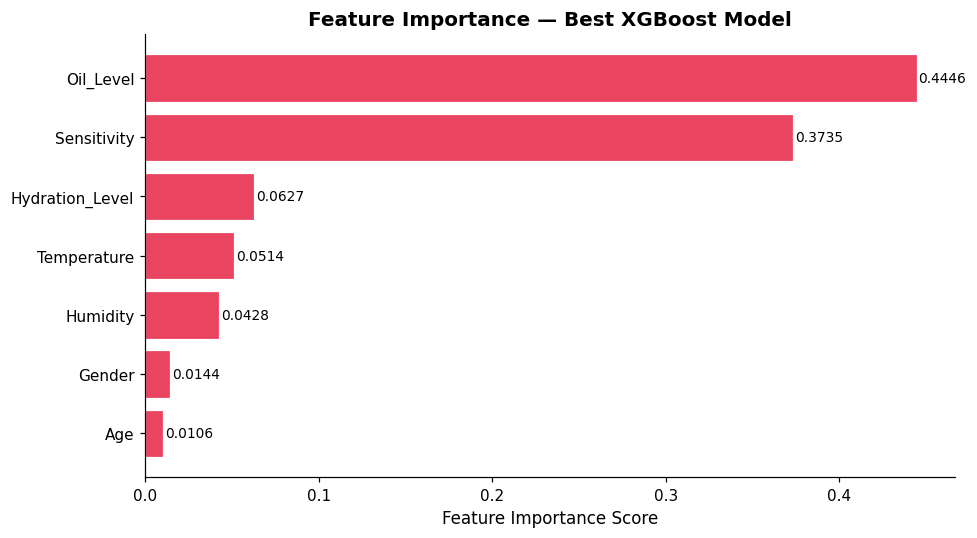

In [33]:
# ── 3. Combined importance — seaborn styled ──────────────────────────────────
imp_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.barh(imp_df['Feature'], imp_df['Importance'],
                color='#e94560', edgecolor='white', linewidth=0.8)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance Score', fontsize=11)
plt.title('Feature Importance — Best XGBoost Model', fontweight='bold', fontsize=13)
for bar, val in zip(bars, imp_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
# ── 4. SHAP values (optional — uncomment after installing) ───────────────────
# !pip install shap --quiet
# import shap
# shap.initjs()
#
# explainer   = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(X_train)
#
# # Summary plot — all classes
# shap.summary_plot(shap_values, X_train, feature_names=FEATURES)
#
# # Force plot — single instance (index 0)
# shap.force_plot(
#     explainer.expected_value[0],
#     shap_values[0][0],
#     X_train.iloc[0, :],
#     feature_names=FEATURES
# )
print("SHAP section is commented out. Uncomment to enable interpretability plots.")

SHAP section is commented out. Uncomment to enable interpretability plots.


---
## 🌲 Step 8 — Visualize a Single Decision Tree

In [37]:
import matplotlib.pyplot as plt
import xgboost as xgb

# 1. Create the giant canvas AND capture the axis (ax)
# dpi=300 forces high-resolution rendering so text doesn't blur when zooming
fig, ax = plt.subplots(figsize=(50, 30), dpi=300)

# 2. Tell XGBoost to plot explicitly on the axis (ax) we just created
xgb.plot_tree(
    best_model,
    num_trees=0,              # first tree
    rankdir='LR',             # left-to-right layout
    ax=ax                     # <--- THIS IS THE MISSING MAGIC KEY
)

plt.title('XGBoost — Tree #0 (first estimator)', fontweight='bold', fontsize=50)
plt.tight_layout()
plt.show()

---
## ✅ Conclusion

<div style="background: #f0f4f8; border-left: 5px solid #e94560; padding: 20px; border-radius: 8px;">

### Results Summary

| Model | Test Accuracy | Notes |
|---|---|---|
| Baseline XGBoost | `acc_base` | Default hyperparameters |
| GridSearchCV (reduced) | `acc_grid` | 384 combos, 3-fold CV |
| **RandomizedSearchCV** | **`acc_rand`** | **40 random combos — best trade-off** |

### Key Takeaways

- **XGBoost handles multiclass natively** via `multi:softmax` — no wrappers needed.
- **Categorical encoding** (LabelEncoder) is necessary since XGBoost expects numeric input.
- **No scaling required** — unlike SVM, XGBoost is scale-invariant by nature.
- **RandomizedSearchCV** achieves near-optimal accuracy in a fraction of the time vs exhaustive GridSearch.
- The most impactful features (from gain importance) guide us on which variables best discriminate skin type.

</div>